In [1]:
import pickle 
import numpy as np
from keras.applications.vgg16 import VGG16
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model
from keras.callbacks import TensorBoard
from keras.models import Model, Sequential
from keras.layers import Input
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Embedding
from keras.layers import Dropout
from keras.layers.merge import add
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Flatten,Input, Bidirectional, Convolution2D, Dropout, LSTM, TimeDistributed, Embedding, Bidirectional, Activation, RepeatVector,Concatenate
from keras.models import Sequential, Model
import matplotlib.pyplot as plt
import datetime
import os
from glob import glob
from keras.applications.resnet50 import ResNet50
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

In [2]:
file = open('../Logs/VGG16_BNG9k/image_features.pickle', "rb")
images_features = pickle.load(file)
file.close()

In [3]:
type(images_features)

dict

In [4]:
caption_path = '../Data/BNG_9k/Captions.txt'
captions = open(caption_path, 'rb').read().decode('utf-8').split('\n')
captions[0]

'1.png#0\tদুই জন মেয়ে মানুষ আছে। এক জন দাড়িয়ে আছে আর এক জন বসে আছে।'

In [5]:
len(captions)//2

9099

In [6]:
len(images_features)

9102

In [7]:
captions_dict = {}
for i in captions:
    try:
        img_name = i.split('\t')[0][:-2] 
        caption = i.split('\t')[1]
        if 'images\\'+img_name in images_features:
            if img_name not in captions_dict:
                captions_dict[img_name] = [caption]
                
            else:
                captions_dict[img_name].append(caption)
            
    except:
        pass

In [8]:
len(captions_dict)

9099

In [9]:
def preprocessed(txt):
    modified = txt
    modified = 'startofseq ' + modified + ' endofseq'
    return modified



In [10]:
for img_name, texts in captions_dict.items():
    for text_content in texts:
        captions_dict[img_name][texts.index(text_content)] = preprocessed(text_content)

In [11]:

word_count = {}
count = 1
for img_name, texts in captions_dict.items():
    for text_content in texts:
        for word in text_content.split():
            if word not in word_count:
                word_count[word] = count
                count += 1




In [12]:
len(word_count)

6433

In [13]:
for img_name, texts in captions_dict.items():
    for text_content in texts:
        encoded = []
        for word in text_content.split():  
            encoded.append(word_count[word])
        captions_dict[img_name][texts.index(text_content)] = encoded

In [14]:
MAX_LEN = 0
for img_name, texts in captions_dict.items():
    for text_content in texts:
        if len(text_content) > MAX_LEN:
            MAX_LEN = len(text_content)
#             print(v)

In [15]:
MAX_LEN

39

In [16]:
VOCAB_SIZE = len(word_count)

def generator(photo, caption):
    n_samples = 0
    
    X = []
    y_in = []
    y_out = []
    
    for k, vv in caption.items():
        for v in vv:
            for i in range(1, len(v)):
                X.append(photo['images\\'+k])

                in_seq= [v[:i]]
                out_seq = v[i]

                in_seq = pad_sequences(in_seq, maxlen=MAX_LEN, padding='post', truncating='post')[0]
                out_seq = to_categorical([out_seq], num_classes=VOCAB_SIZE + 1)[0]

                y_in.append(in_seq)
                y_out.append(out_seq)
            
    return X, y_in, y_out

In [17]:
X, y_in, y_out = generator(images_features, captions_dict)

In [18]:
len(X), len(y_in), len(y_out)

(171205, 171205, 171205)

In [19]:
X[0]

array([2.1625462, 0.       , 0.       , ..., 0.       , 0.       ,
       0.       ], dtype=float32)

In [20]:
y_in[0]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [21]:
y_out[0]

array([0., 0., 1., ..., 0., 0., 0.], dtype=float32)

In [22]:
X = np.array(X)
y_in = np.array(y_in, dtype='float64')
y_out = np.array(y_out, dtype='float64')

In [23]:
X.shape, y_in.shape, y_out.shape

((171205, 4096), (171205, 39), (171205, 6434))

In [24]:
embedding_size = 128
max_len = MAX_LEN
vocab_size = len(word_count) + 1


image_model = Sequential()
image_model.add(Dense(embedding_size, input_shape=(4096,), activation='relu'))
image_model.add(RepeatVector(max_len))

image_model.summary()



Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               524416    
_________________________________________________________________
repeat_vector (RepeatVector) (None, 39, 128)           0         
Total params: 524,416
Trainable params: 524,416
Non-trainable params: 0
_________________________________________________________________


In [25]:
language_model = Sequential()

language_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=max_len))
language_model.add(Bidirectional(LSTM(512, return_sequences=True))) #256
language_model.add(TimeDistributed(Dense(embedding_size)))

language_model.summary()



Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 39, 128)           823552    
_________________________________________________________________
bidirectional (Bidirectional (None, 39, 1024)          2625536   
_________________________________________________________________
time_distributed (TimeDistri (None, 39, 128)           131200    
Total params: 3,580,288
Trainable params: 3,580,288
Non-trainable params: 0
_________________________________________________________________


In [26]:
conca = Concatenate()([image_model.output, language_model.output])
x = Bidirectional(LSTM(256, return_sequences=True))(conca)#128
# x = LSTM(256, return_sequences=False)(x)
x = Bidirectional(LSTM(512, return_sequences=False))(x)
x = Dense(vocab_size)(x)
out = Activation('softmax')(x)


model = Model(inputs=[image_model.input, language_model.input], outputs = out)


model.compile(loss='categorical_crossentropy', optimizer='RMSprop', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
embedding_input (InputLayer)    [(None, 39)]         0                                            
__________________________________________________________________________________________________
dense_input (InputLayer)        [(None, 4096)]       0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 39, 128)      823552      embedding_input[0][0]            
__________________________________________________________________________________________________
dense (Dense)                   (None, 128)          524416      dense_input[0][0]                
______________________________________________________________________________________________

In [27]:
NAME = 'caption_model_RMSprop_BidirectionalLstm_512_256_512_{}'.format(datetime.datetime.now().strftime("%d.%m.%Y-%H_%M"))
logdir = os.path.join("../Logs/VGG16_BNG9k/logs", NAME)
t_board = TensorBoard(log_dir = logdir)

In [28]:
history = model.fit([X, y_in], y_out, batch_size=485, epochs=90, callbacks = [t_board])

Epoch 1/90
353/353 [==============================] - 175s 463ms/step - loss: 5.4151 - accuracy: 0.1342
Epoch 2/90
353/353 [==============================] - 161s 455ms/step - loss: 4.2830 - accuracy: 0.2397
Epoch 3/90
353/353 [==============================] - 161s 456ms/step - loss: 3.7687 - accuracy: 0.3017
Epoch 4/90
353/353 [==============================] - 161s 456ms/step - loss: 3.4959 - accuracy: 0.3351
Epoch 5/90
353/353 [==============================] - 161s 456ms/step - loss: 3.2749 - accuracy: 0.3655
Epoch 6/90
353/353 [==============================] - 161s 456ms/step - loss: 3.1135 - accuracy: 0.3886
Epoch 7/90
353/353 [==============================] - 161s 456ms/step - loss: 2.9846 - accuracy: 0.4039
Epoch 8/90
353/353 [==============================] - 161s 456ms/step - loss: 2.8276 - accuracy: 0.4258
Epoch 9/90
353/353 [==============================] - 161s 456ms/step - loss: 2.7052 - accuracy: 0.4463
Epoch 10/90
353/353 [==============================] - 161s 456m

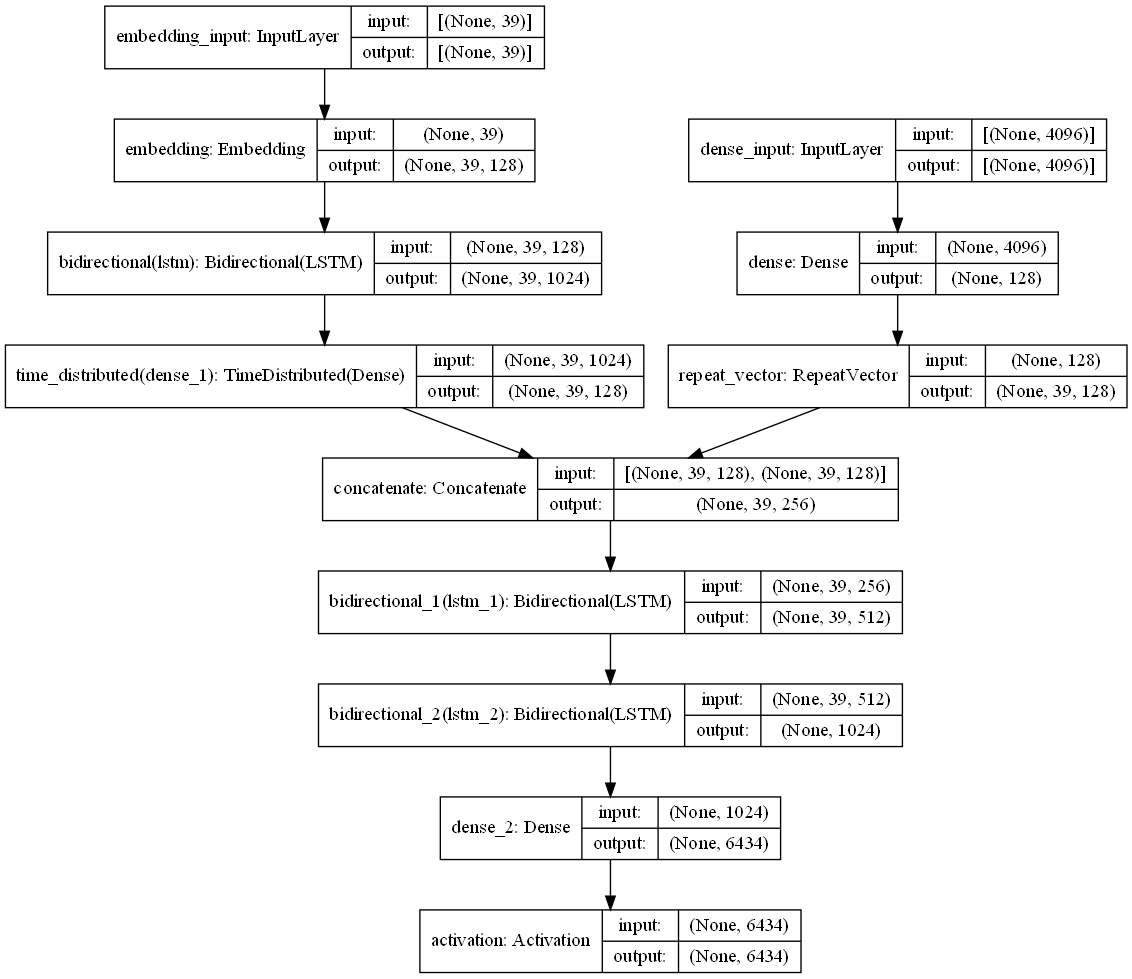

In [29]:
plot_model(model,to_file=logdir+'\\'+'model.png', show_shapes=True,dpi=98)

In [30]:
model.save(logdir+'\\'+NAME+'.hdf5')

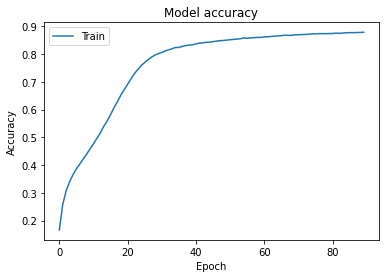

In [31]:
# Plot training & validation accuracy values
fig, ax = plt.subplots(1,1)
plt.plot(history.history["accuracy"])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


fig.savefig(logdir+'\\'+'model1_train_test_accuracy.jpeg',dpi=93)

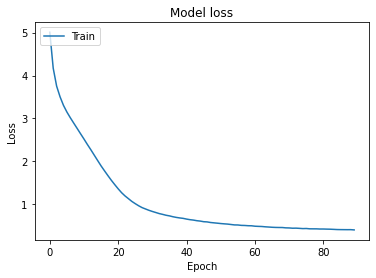

In [32]:
# Plot training & validation loss values
fig, ax = plt.subplots(1,1)
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
fig.savefig(logdir+'\\'+'model1_train_test_los.jpeg',dpi=93)

In [33]:
assert False

AssertionError: 

In [ ]:

images_path = '../Data/BNG_9k/images/'
images = glob(images_path+'*.png')

In [ ]:
def getImage(x):
    
    test_img_path = images[x]

    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    test_img = cv2.resize(test_img, (224,224))

    test_img = np.reshape(test_img, (1,224,224,3))
    
    return test_img

In [ ]:


feature_model = ResNet50(include_top=True)
extractor = Model(inputs = feature_model.input,outputs = feature_model.layers[-2].output)

# model = tf.keras.models.load_model('../Logs/ResNet50_BNG9k/logs/caption_model_RMSprop_lstm_128_512_20.06.2021-04_36/caption_model_RMSprop_lstm_128_512_20.06.2021-04_36.hdf5')


In [ ]:
inv_dict = {v:k for k, v in word_count.items()}

In [ ]:
for m in range(15):
    
    no = np.random.randint(1500,7000,(1,1))[0,0]
    test_feature = extractor.predict(getImage(no)).reshape(1,2048)
    
    test_img_path = images[no]
    test_img = cv2.imread(test_img_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    print(images[no].split('\\')[-1])
    plt.imshow(test_img)
    plt.axis('off')
    plt.show()

    text_inp = ['startofseq']

    count = 0
    caption = ''
    while count < 25:
        count += 1

        encoded = []
        for i in text_inp:
            encoded.append(word_count[i])

        encoded = [encoded]

        encoded = pad_sequences(encoded, padding='post', truncating='post', maxlen=25)


        prediction = np.argmax(model.predict([test_feature, encoded]))

        sampled_word = inv_dict[prediction]

        
            
        if sampled_word == 'endofseq':
            break
        else:
            caption = caption + ' ' + sampled_word

        text_inp.append(sampled_word)
    

    
       
    print(caption)